<a href="https://colab.research.google.com/github/safiraroha26/student_graduation_prediction/blob/main/graduation_klasifikasi-prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATA LOADING

In [ ]:
import pandas as pd

data = [
["A1",1,60,55,58,0],
["A2",2,65,60,62,0],
["A3",2,70,65,68,0],
["A4",3,75,70,72,1],
["A5",4,80,75,78,1],
["A6",5,85,80,85,1],
["A7",6,90,88,90,1],
["A8",1,55,50,54,0],
["A9",3,78,72,75,1],
["A10",2,68,63,66,0],
["A11",4,82,77,80,1],
["A12",5,88,85,87,1],
["A13",6,92,90,93,1],
["A14",1,58,52,56,0],
["A15",3,72,68,70,1]
]

columns = ["Nama","Jam_Belajar","Kehadiran","Nilai_Tugas","Nilai_Ujian","Status_Lulus"]

df = pd.DataFrame(data, columns=columns)

df

,Nama,Jam_Belajar,Kehadiran,Nilai_Tugas,Nilai_Ujian,Status_Lulus
0,A1,1,60,55,58,0
1,A2,2,65,60,62,0
2,A3,2,70,65,68,0
3,A4,3,75,70,72,1
4,A5,4,80,75,78,1
5,A6,5,85,80,85,1
6,A7,6,90,88,90,1
7,A8,1,55,50,54,0
8,A9,3,78,72,75,1
9,A10,2,68,63,66,0


# DATA CLEANING

In [ ]:
print("Missing Values:")
print(df.isnull().sum())

print("\nInfo Dataset:")
print(df.info())

Missing Values:
Nama            0
Jam_Belajar     0
Kehadiran       0
Nilai_Tugas     0
Nilai_Ujian     0
Status_Lulus    0
dtype: int64

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Nama          15 non-null     object
 1   Jam_Belajar   15 non-null     int64 
 2   Kehadiran     15 non-null     int64 
 3   Nilai_Tugas   15 non-null     int64 
 4   Nilai_Ujian   15 non-null     int64 
 5   Status_Lulus  15 non-null     int64 
dtypes: int64(5), object(1)
memory usage: 852.0+ bytes
None


# FEATURE SELECTION

In [ ]:
X = df[["Jam_Belajar","Kehadiran","Nilai_Tugas","Nilai_Ujian"]]
y = df["Status_Lulus"]

X.head()

,Jam_Belajar,Kehadiran,Nilai_Tugas,Nilai_Ujian
0,1,60,55,58
1,2,65,60,62
2,2,70,65,68
3,3,75,70,72
4,4,80,75,78


# DATA SPLITTING

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Data Training:", len(X_train))
print("Data Testing:", len(X_test))

Data Training: 10
Data Testing: 5


# MODELLING

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# EVALUATION

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
 [[3 0]
 [0 2]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         2

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



# VISUALISASI

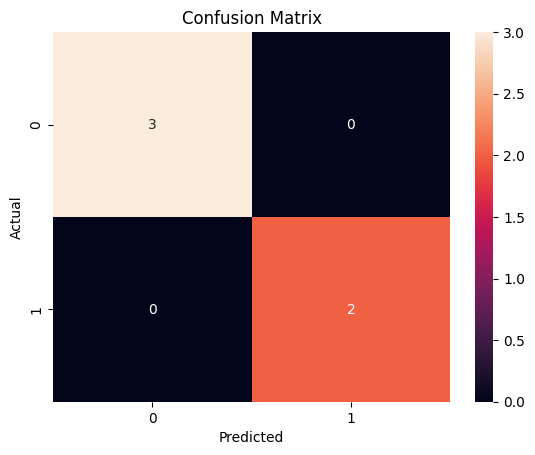

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# PREDIKSI BARU

In [ ]:
siswa_baru = pd.DataFrame(
    [[2,70,65,68]],
    columns=["Jam_Belajar","Kehadiran","Nilai_Tugas","Nilai_Ujian"]
)

prediksi = model.predict(siswa_baru)
probabilitas = model.predict_proba(siswa_baru)

print("Prediksi Status Lulus (0=TIDAK LULUS, 1=LULUS):", prediksi[0])
print("Probabilitas [Tidak Lulus, Lulus]:", probabilitas)

Prediksi Status Lulus (0=TIDAK LULUS, 1=LULUS): 0
Probabilitas [Tidak Lulus, Lulus]: [[0.83011609 0.16988391]]
